In [ ]:
# ============================================================
# POTATO DISEASE CLASSIFICATION
# MobileNetV2 ONLY
# Classes: Early Blight, Late Blight, Healthy
# ============================================================

import os
import zipfile
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow:", tf.__version__)

# ============================================================
# 1. ZIP PATH
# ============================================================

ZIP_PATH = "/content/Potato.zip"
EXTRACT_PATH = "/content/Potato_dataset"

# Clean previous extraction
if os.path.exists(EXTRACT_PATH):
    shutil.rmtree(EXTRACT_PATH)

os.makedirs(EXTRACT_PATH, exist_ok=True)

# ============================================================
# 2. EXTRACT COMPLETE ZIP
# ============================================================

if not os.path.isfile(ZIP_PATH):
    raise FileNotFoundError(
        f"Potato ZIP not found: {ZIP_PATH}"
    )

print("ZIP:", ZIP_PATH)
print("Extracting...")

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_PATH)

print("Extraction completed.")

# ============================================================
# 3. FIND ACTUAL CLASS FOLDER
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

def find_class_root(root):

    candidates = []

    for current_root, dirs, files in os.walk(root):

        image_dirs = []

        for d in dirs:

            folder = os.path.join(
                current_root,
                d
            )

            try:

                has_image = any(
                    f.lower().endswith(IMAGE_EXTENSIONS)
                    for f in os.listdir(folder)
                )

                if has_image:
                    image_dirs.append(d)

            except PermissionError:
                continue

        # Potato dataset should have 3 class folders
        if len(image_dirs) == 3:

            candidates.append(
                (
                    current_root,
                    sorted(image_dirs)
                )
            )

    if not candidates:

        raise RuntimeError(
            "Could not find the 3 Potato class folders."
        )

    # Prefer the shallowest suitable directory
    candidates.sort(
        key=lambda x: x[0].count(os.sep)
    )

    return candidates[0]


DATASET_PATH, classes = find_class_root(
    EXTRACT_PATH
)

print("\nDataset folder:")
print(DATASET_PATH)

print("\nClasses:")
for i, c in enumerate(classes):
    print(i, "->", c)

print("\nNumber of classes:", len(classes))

assert len(classes) == 3, (
    f"Expected 3 Potato classes, found {len(classes)}"
)

# ============================================================
# 4. COUNT IMAGES
# ============================================================

total_images = 0

for cls in classes:

    folder = os.path.join(
        DATASET_PATH,
        cls
    )

    count = sum(
        f.lower().endswith(IMAGE_EXTENSIONS)
        for f in os.listdir(folder)
    )

    print(f"{cls}: {count} images")

    total_images += count

print("\nTotal Potato images:", total_images)

TensorFlow: 2.20.0
ZIP: /content/Potato.zip
Extracting...
Extraction completed.

Dataset folder:
/content/Potato_dataset/Potato

Classes:
0 -> Potato___Early_blight
1 -> Potato___Late_blight
2 -> Potato___healthy

Number of classes: 3
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images

Total Potato images: 2152


In [ ]:
# ============================================================
# IMAGE SETTINGS
# ============================================================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# ============================================================
# MOBILENETV2 PREPROCESSING
# ============================================================

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# ============================================================
# TRAIN GENERATOR
# ============================================================

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess,

    validation_split=0.20,

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)

# ============================================================
# VALIDATION GENERATOR
# ============================================================

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    classes=classes,

    class_mode="categorical",

    subset="training",

    shuffle=True,

    seed=SEED
)

val_generator = val_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    classes=classes,

    class_mode="categorical",

    subset="validation",

    shuffle=False,

    seed=SEED
)

print("\nTraining images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Total:", train_generator.samples + val_generator.samples)

print("\nClass mapping:")
print(train_generator.class_indices)

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.

Training images: 1722
Validation images: 430
Total: 2152

Class mapping:
{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [ ]:
# ============================================================
# MOBILENETV2 ONLY
# ============================================================

base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224, 224, 3),

    include_top=False,

    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Potato_MobileNetV2"
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Potato_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# COMPILE
# ============================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

def lr_schedule(epoch, lr):

    if epoch < 20:
        return 1e-4

    elif epoch < 60:
        return 5e-5

    elif epoch < 100:
        return 2e-5

    elif epoch < 150:
        return 1e-5

    else:
        return 5e-6


lr_callback = tf.keras.callbacks.LearningRateScheduler(
    lr_schedule,
    verbose=1
)


# ============================================================
# BEST MODEL
# ============================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "/content/Potato_MobileNetV2_best.keras",

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    verbose=1
)


# ============================================================
# TRAIN 200 EPOCHS
# NO EARLY STOPPING
# ============================================================

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    callbacks=[
        lr_callback,
        checkpoint
    ],

    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.3906 - loss: 1.2448
Epoch 1: val_accuracy improved from None to 0.62791, saving model to /content/Potato_MobileNetV2_best.keras

Epoch 1: finished saving model to /content/Potato_MobileNetV2_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4477 - loss: 1.1412 - val_accuracy: 0.6279 - val_loss: 0.8250 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5778 - loss: 0.8973
Epoch 2: val_accuracy improved from 0.62791 to 0.76047, saving model to /content/Potato_MobileNetV2_best.keras

Epoch 2: finished saving model to /content/Potato_MobileNetV2_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 432ms/step - accuracy: 0.6080 - loss: 0.8609 - val_accuracy: 0.7605 - val_loss: 0.6398 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting le

In [ ]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

best_model = tf.keras.models.load_model(
    "/content/Potato_MobileNetV2_best.keras"
)

# ============================================================
# PREDICTION
# ============================================================

val_generator.reset()

pred_prob = best_model.predict(
    val_generator,
    verbose=1
)

y_pred = np.argmax(
    pred_prob,
    axis=1
)

y_true = val_generator.classes

print("Predictions:", len(y_pred))
print("True labels:", len(y_true))

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 450ms/step
Predictions: 430
True labels: 430


In [ ]:
# ============================================================
# ACCURACY
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4
    )
)

Accuracy  : 0.9279
Accuracy  : 92.79%
Precision : 0.9285
Recall    : 0.9279
F1 Score  : 0.9253
                       precision    recall  f1-score   support

Potato___Early_blight     0.9793    0.9450    0.9618       200
 Potato___Late_blight     0.8894    0.9650    0.9257       200
     Potato___healthy     0.8500    0.5667    0.6800        30

             accuracy                         0.9279       430
            macro avg     0.9062    0.8256    0.8558       430
         weighted avg     0.9285    0.9279    0.9253       430



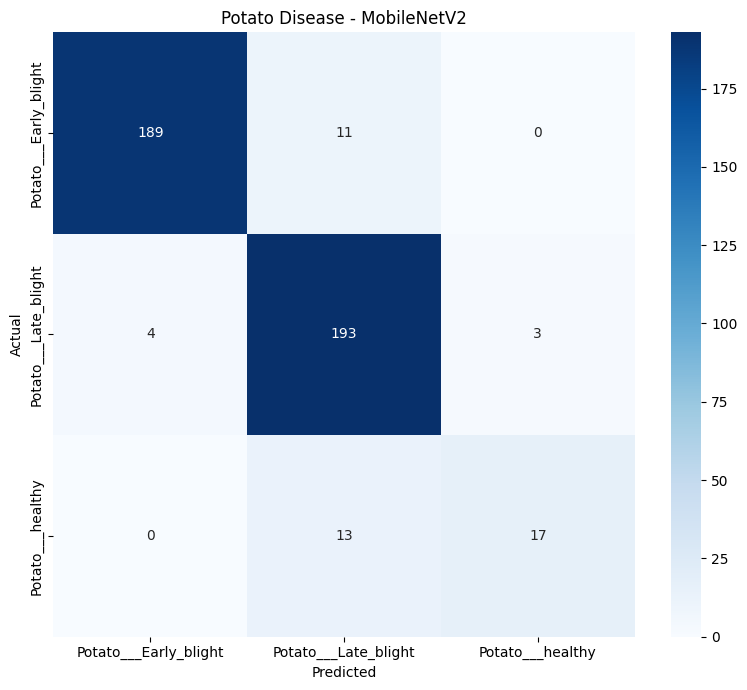

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Potato Disease - MobileNetV2")

plt.tight_layout()
plt.show()

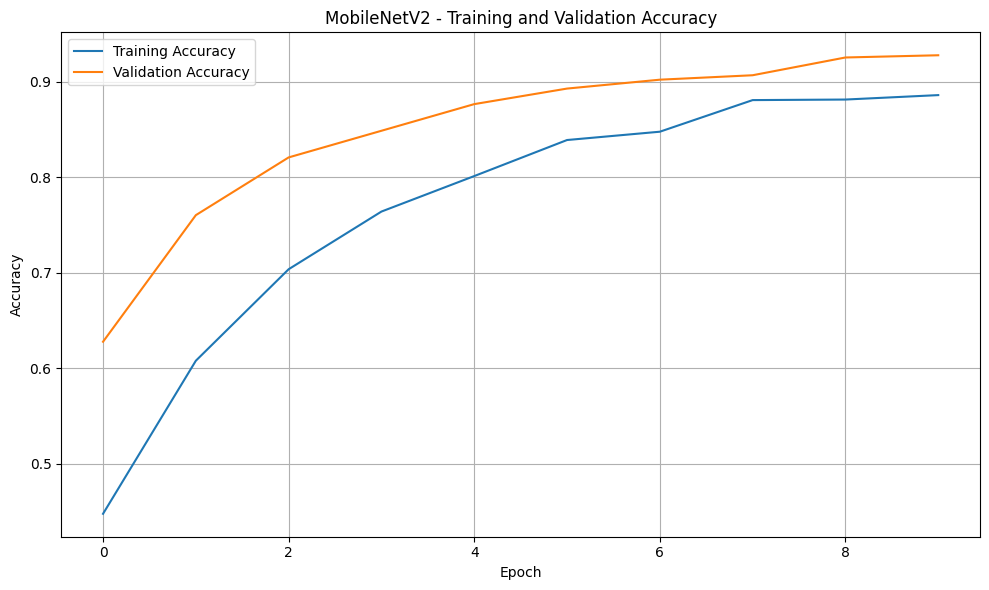

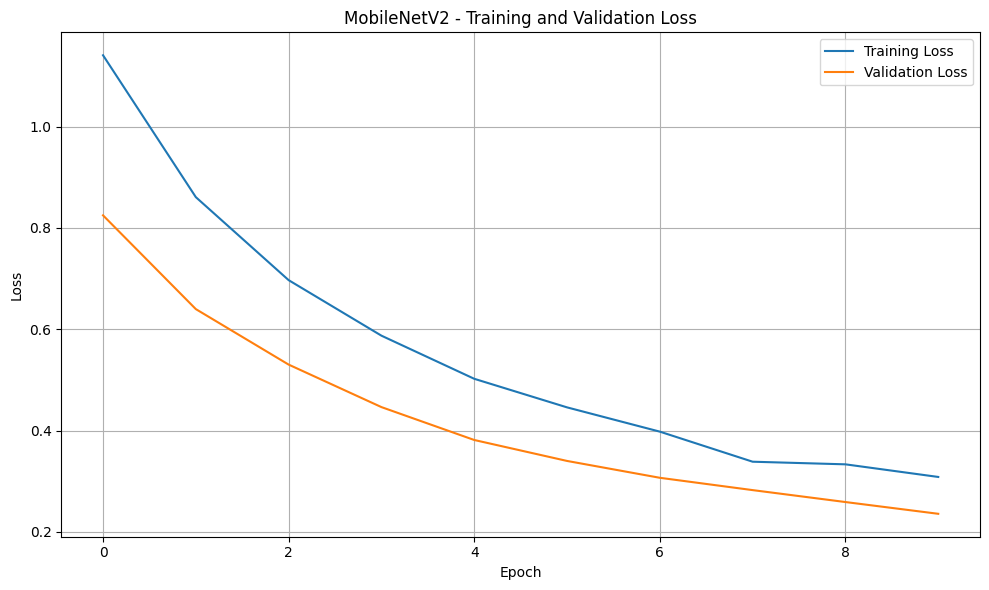

In [ ]:
# ============================================================
# ACCURACY AND LOSS PLOTS
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# Accuracy
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------
# Loss
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()